# Sea-state scatter diagram with wave-steepness limit

Scatter of the $(T_p, H_s)$ sea states, coloured by severity, with the maximum
wave-steepness curve overlaid.

**Steepness definition**
$$ S_p = \frac{2\pi}{g}\,\frac{H_s}{T_p^{2}} $$

**Limit (DNV)** — interpolated linearly in between:
$$ S_p = \tfrac{1}{15}\ \text{for}\ T_p \le 8\,\text{s}, \qquad S_p = \tfrac{1}{25}\ \text{for}\ T_p \ge 15\,\text{s} $$

Solving for $H_s$ gives the limiting curve $H_s^{\max}(T_p) = S_p(T_p)\,\dfrac{g\,T_p^{2}}{2\pi}$.
Sea states above this line are too steep (breaking), which is why high $H_s$ only
appears at large $T_p$.

In [36]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81  # gravitational acceleration [m/s^2]

## Sea states

Peak periods $T_p$ [s] listed per significant wave height $H_s$ [m].

In [37]:
sea_states = {
    1: [3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 8.5, 9.0, 9.5, 10.0, 11.0, 12.0],
    2: [3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 8.5, 9.0, 9.5, 10.0, 11.0, 12.0],
    4: [7.0, 8.0, 8.5, 9.0, 9.5, 10.0, 11.0, 12.0],
    6: [9.0, 9.5, 10.0, 11.0, 12.0],
    8: [9.0, 9.5, 10.0, 11.0, 12.0],
}

# Two severity categories: mild (Hs <= 4 m) and extreme (Hs >= 6 m).
# Individual Hs values are read off the y-axis, so colour only encodes severity.
def category(hs):
    return "Mild seastates" if hs <= 4 else "Extreme seastates"

cat_style = {
    "Mild seastates":    {"c": "#378ADD", "marker": "o"},   # calm  -> cool blue
    "Extreme seastates": {"c": "#E24B4A", "marker": "^"},   # severe -> warm red
}

## Steepness limit

In [38]:
def steepness_limit(Tp):
    """Maximum wave steepness Sp as a function of Tp [s]."""
    Tp = np.asarray(Tp, dtype=float)
    return np.where(Tp <= 8, 1/15,
           np.where(Tp >= 15, 1/25,
                    1/15 + (1/25 - 1/15) * (Tp - 8) / (15 - 8)))

def Hs_limit(Tp):
    """Limiting significant wave height [m]: Hs = Sp * g * Tp^2 / (2*pi)."""
    Tp = np.asarray(Tp, dtype=float)
    return steepness_limit(Tp) * g * Tp**2 / (2 * np.pi)

## Plot

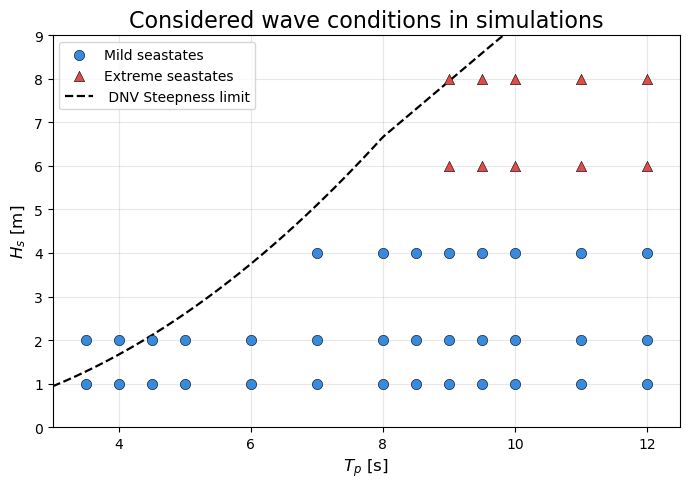

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))

# Scatter, one legend entry per category (mild / extreme).
labelled = set()
for hs, tps in sea_states.items():
    cat = category(hs)
    style = cat_style[cat]
    ax.scatter(tps, [hs] * len(tps),
               c=style["c"], marker=style["marker"], s=55,
               edgecolors="black", linewidths=0.4, zorder=3,
               label=cat if cat not in labelled else None)
    labelled.add(cat)

# Steepness limit.
Tp = np.linspace(3, 13, 300)
ax.plot(Tp, Hs_limit(Tp), "k--", lw=1.6, zorder=2,
        label=" DNV Steepness limit")

ax.set_xlabel("$T_p$ [s]", fontsize=12)
ax.set_ylabel("$H_s$ [m]", fontsize=12)
ax.set_xlim(3, 12.5)
ax.set_ylim(0, 9)
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=10)
ax.set_title(f"Considered wave conditions in simulations", fontsize=16)
fig.tight_layout()
plt.show()